Phase 1: Problem Understanding & Objective Definition

Understand customer sentiment expressed on Twitter toward airline services.
Identify key aspects/themes (e.g., delays, service, baggage).
Analyze how sentiment varies across these aspects.

Phase 2: Data Collection & Intial Exploration

In [2]:
import pandas as pd
df= pd.read_csv("Tweets.csv")

In [3]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df.shape

(14640, 15)

In [6]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [7]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [8]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

Phase 3: Data Cleaning and Text Preprocessing

In [10]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rutuja\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [11]:
stop_words=set(stopwords.words('english'))

In [12]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'http\S+|www\S+','',text)
    text=re.sub(r'@\w+','',text)
    text=re.sub(r'#\w+','',text)
    text=re.sub(r'[^a-z\s]','',text)
    text=text.split()
    text= [word for word in text if word not in stop_words]
    return " ".join(text)

In [13]:
df['clean_text']=df['text'].apply(clean_text)

In [14]:
df[['text', 'clean_text']].head(5)


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


In [15]:
df['clean_text'].str.len().min()

0

Text data was cleaned by removing URLs, mentions, hashtags, punctuation, and stopwords to reduce noise and improve feature quality for downstream NLP tasks.

Phase 4: EDA 

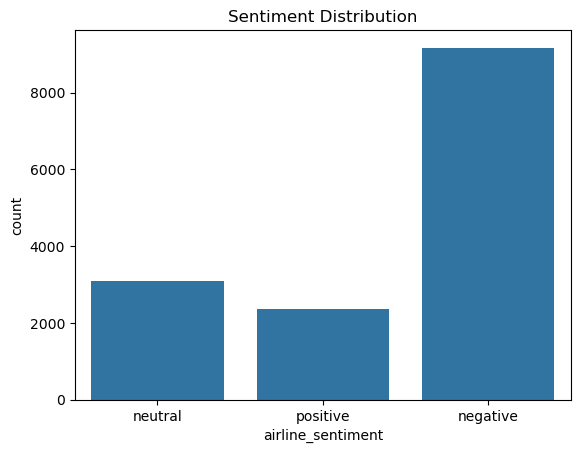

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='airline_sentiment',data=df)
plt.title("Sentiment Distribution")
plt.show()

In [24]:
df['text_length']=df['clean_text'].apply(len)
df.groupby('airline_sentiment')['text_length'].mean()

airline_sentiment
negative    62.585369
neutral     43.306844
positive    44.071217
Name: text_length, dtype: float64

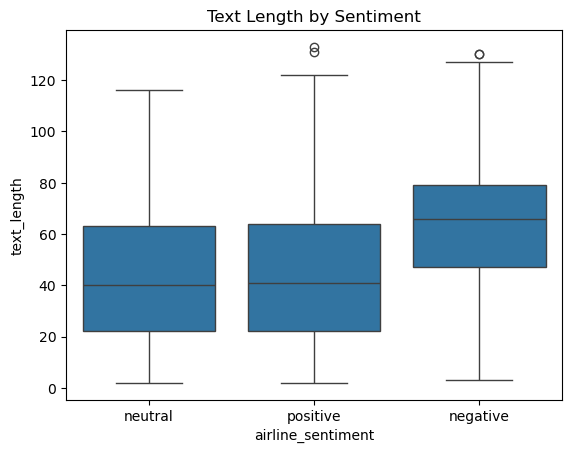

In [25]:
sns.boxplot(x='airline_sentiment',y='text_length',data=df)
plt.title("Text Length by Sentiment")
plt.show()

In [26]:
pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index')


airline_sentiment,negative,neutral,positive
airline,,,
American,0.711071,0.166969,0.121960
Delta,0.430568,0.324166,0.245266
Southwest,0.491090,0.273104,0.235806
US Airways,0.777434,0.130719,0.091847
United,0.689366,0.182032,0.128601
Virgin America,0.359841,0.337972,0.302187


In [21]:
# Drop rows where clean_text is empty
df = df[df['clean_text'].str.len() > 0]


In [22]:
df['clean_text'].str.len().min(), df.shape

(2, (14614, 17))

Negative tweets dominate the dataset, indicating that Twitter is primarily used for complaints in the airline context.

Negative tweets tend to be longer on average, suggesting detailed issue reporting by users.

Phase 5: Feature Engineering(TF-IDF)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
X=df['clean_text']
y=df['airline_sentiment']

vectorizer=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5)

X_tfidf=vectorizer.fit_transform(X)
X_tfidf.shape


(14614, 4489)

Phase 6:Sentiment Classification Model

In [30]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test= train_test_split(
    X_tfidf,
    y,test_size=0.2,
    random_state=42,stratify=y)

In [32]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    max_iter=1000,
    class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred= model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.89      0.78      0.83      1834
     neutral       0.52      0.65      0.58       617
    positive       0.65      0.73      0.69       472

    accuracy                           0.75      2923
   macro avg       0.69      0.72      0.70      2923
weighted avg       0.77      0.75      0.76      2923



In [35]:
confusion_matrix(y_test, y_pred)


array([[1437,  292,  105],
       [ 135,  401,   81],
       [  48,   78,  346]])

The model achieves an overall accuracy of 75% with strong performance on the negative class (F1-score: 0.83). Neutral sentiment remains the most challenging to classify due to linguistic ambiguity, which is consistent with real-world sentiment analysis tasks.

Phase 7:Aspect/Theme Extraction(KMeans)


In [37]:
from sklearn.cluster import KMeans

kmeans=KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10)

clusters=kmeans.fit_predict(X_tfidf)
df['aspect_cluster']=clusters

In [40]:
terms = vectorizer.get_feature_names_out()

for i in range(5):
    center= kmeans.cluster_centers_[i]
    top_terms=[terms[ind] for ind in center.argsort()[-10:]]
    print(f"Cluster {i}: {top_terms}")

Cluster 0: ['cancelled flighted', 'flight cancelled', 'late flight', 'get', 'late', 'delayed', 'flightled', 'cancelled flightled', 'cancelled', 'flight']
Cluster 1: ['help', 'response', 'reply', 'thanks help', 'great', 'got', 'flight', 'much', 'thanks much', 'thanks']
Cluster 2: ['call', 'get', 'ive', 'flight', 'still', 'minutes', 'hour', 'waiting', 'hold', 'hours']
Cluster 3: ['poor', 'hold', 'flight', 'ever', 'terrible', 'worst', 'worst customer', 'service', 'customer', 'customer service']
Cluster 4: ['one', 'time', 'would', 'flights', 'us', 'please', 'help', 'im', 'get', 'thank']


In [42]:
aspect_map={
    0: 'Flight Delays & Cancellations',
    1: 'Customer Suppor Response(Positive)',
    2: 'Call Center Waiting Time',
    3: 'Poor Customer Service Experiences',
    4: 'General Service Requests & Inquiries'}

df['aspects']=df['aspect_cluster'].map(aspect_map)


Unsupervised clustering was applied to TF-IDF features to identify dominant discussion themes. Each cluster was manually interpreted and labeled based on its most representative keywords.

Phase 8: Aspect-Wise Sentiment Analysis

In [54]:
aspect_sentiment=(
    df.groupby(['aspects','airline_sentiment'])
        .size()
        .unstack(fill_value=0)
)

aspect_sentiment

airline_sentiment,negative,neutral,positive
aspects,,,
Call Center Waiting Time,1013,41,12
Customer Suppor Response(Positive),146,123,498
Flight Delays & Cancellations,2229,535,247
General Service Requests & Inquiries,5326,2360,1505
Poor Customer Service Experiences,458,24,97


Aspect-wise sentiment analysis reveals that flight delays, cancellations, and call center waiting times are the primary drivers of negative sentiment. In contrast, customer support interactions show strong positive sentiment when timely responses are provided, highlighting response efficiency as a key improvement area.